### Markov Switching AR
- 3-상태 모델 (정상/과열/저평가)

#### Baseline (gap 단변량 → 1년 확률 시뮬레이션)

In [14]:
# =========================
# [셀 1] 데이터 로드
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.regime_switching.markov_autoregression import MarkovAutoregression

df = pd.read_csv("data/decoupling.csv", encoding="utf-8-sig")
df["date"] = pd.to_datetime(df["date"])
df = df.set_index("date").sort_index().asfreq("MS")

# gap 정리
y = pd.to_numeric(df["gap"], errors="coerce").interpolate(limit_direction="both").dropna()

print("기간:", y.index.min().date(), "~", y.index.max().date(), "| 관측치:", len(y))

기간: 2005-01-01 ~ 2025-11-01 | 관측치: 251


In [15]:
# =========================
# [셀 2] 2-state MS-AR(1) 학습
# =========================
# switching_ar=True: 상태별 AR 계수 다르게
# switching_variance=True: 상태별 변동성(분산) 다르게

model = MarkovAutoregression(
    y,
    k_regimes=2,
    order=1,
    switching_ar=True,
    switching_variance=True
)

res = model.fit(em_iter=30, search_reps=30, search_iter=20, disp=False)
print(res.summary())

                         Markov Switching Model Results                         
Dep. Variable:                      gap   No. Observations:                  250
Model:             MarkovAutoregression   Log Likelihood                -219.509
Date:                  Tue, 24 Feb 2026   AIC                            455.018
Time:                          13:47:05   BIC                            483.190
Sample:                      01-01-2005   HQIC                           466.357
                           - 11-01-2025                                         
Covariance Type:                 approx                                         
                             Regime 0 parameters                              
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.6164      0.051     12.158      0.000       0.517       0.716
sigma2         0.1212      0.026    

In [16]:
# =========================
# [셀 3] 과열 상태 자동 판별
# =========================
smoothed = res.smoothed_marginal_probabilities

probs = pd.DataFrame(
    {"P_state0": smoothed[0], "P_state1": smoothed[1]},
    index=y.index
)

# 상태별 평균 gap 추정(가중평균 방식이 안정적)
mean0 = float((y * probs["P_state0"]).sum() / probs["P_state0"].sum())
mean1 = float((y * probs["P_state1"]).sum() / probs["P_state1"].sum())

overheat_state = 0 if mean0 > mean1 else 1
normal_state = 1 - overheat_state

print("state0 평균 gap(가중):", round(mean0, 4))
print("state1 평균 gap(가중):", round(mean1, 4))
print("=> 과열(overheat)로 판별된 상태:", overheat_state)

state0 평균 gap(가중): 0.6179
state1 평균 gap(가중): -0.2237
=> 과열(overheat)로 판별된 상태: 0


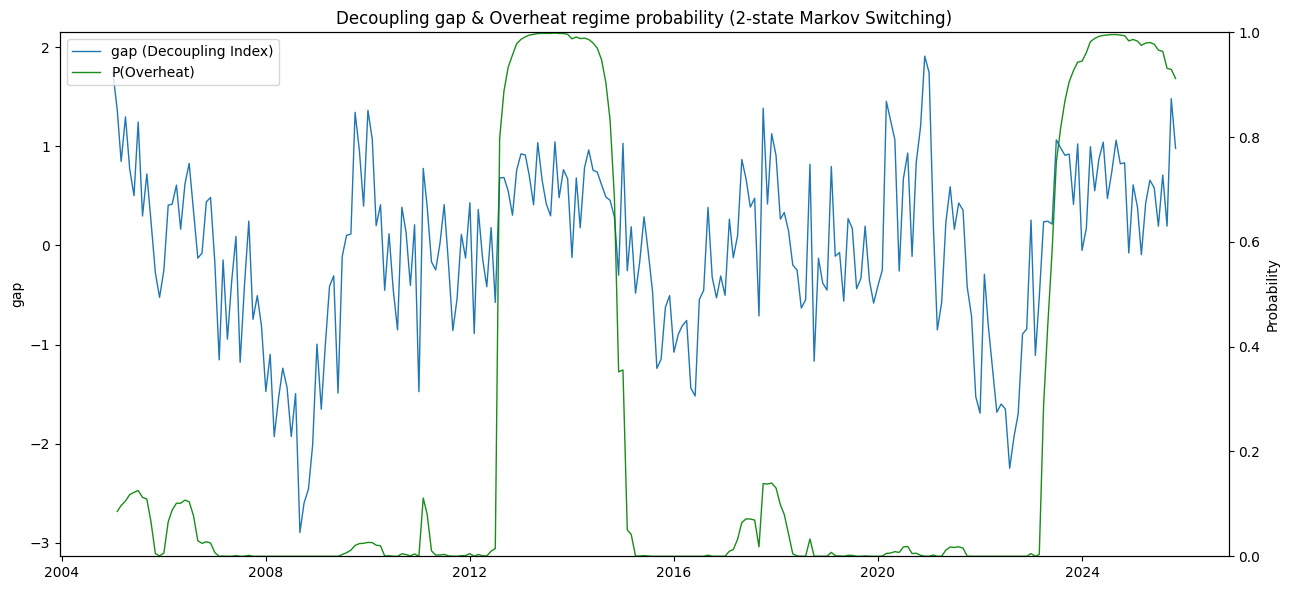

In [19]:
# =========================
# [셀 4] gap + 과열확률 그래프
# =========================
p_overheat = probs[f"P_state{overheat_state}"]

fig, ax1 = plt.subplots(figsize=(13,6))

# gap
ax1.plot(y.index, y.values, linewidth=1, label="gap (Decoupling Index)")
ax1.set_ylabel("gap")

# 과열 확률(오른쪽 축)
ax2 = ax1.twinx()
ax2.plot(p_overheat.index, p_overheat.values, linewidth=1, label="P(Overheat)", alpha=0.9, color= 'green')
ax2.set_ylim(0, 1)
ax2.set_ylabel("Probability")

ax1.set_title("Decoupling gap & Overheat regime probability (2-state Markov Switching)")

# 범례 합치기
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.tight_layout()
plt.show()

In [25]:
# =========================
# [셀 5] 전이확률행렬 확인 (완전 방어 + shape 보정)
# =========================
import numpy as np
import pandas as pd

def get_transition_matrix_any(res, pick="last"):
    """
    pick: 'last' (마지막 시점 전이행렬), 'mean'(기간 평균 전이행렬)
    반환: (k,k) 전이확률행렬
    """

    # regimes 수 추정
    k = getattr(res.model, "k_regimes", None) or getattr(res, "k_regimes", None)
    if k is None:
        try:
            k = res.smoothed_marginal_probabilities.shape[1]
        except Exception:
            k = 2

    # 1) res.transition_matrices (고정 P)
    if hasattr(res, "transition_matrices"):
        P = np.asarray(res.transition_matrices, dtype=float)
        P = np.squeeze(P)
        if P.ndim == 3:  # (k,k,T)로 들어오면 마지막 사용
            P = P[:, :, -1]
        return P

    # 2) model.transition_matrix (고정 P, callable일 수도)
    if hasattr(res.model, "transition_matrix"):
        P = res.model.transition_matrix
        if callable(P):
            try:
                P = P(res.params)
            except TypeError:
                P = P()
        P = np.asarray(P, dtype=float)
        P = np.squeeze(P)
        if P.ndim == 3:
            P = P[:, :, -1]
        return P

    # 3) TVTP: model.regime_transition(params) -> (k,k,T)
    if hasattr(res.model, "regime_transition"):
        try:
            P = res.model.regime_transition(res.params)
            P = np.asarray(P, dtype=float)
            if P.ndim == 3:
                return P.mean(axis=2) if pick == "mean" else P[:, :, -1]
            if P.ndim == 2:
                return P
        except Exception:
            pass

    # 4) 최후: param_names에서 p00/p11 찾아 구성
    param_names = getattr(res.model, "param_names", None) or getattr(res, "param_names", None) or []
    params = np.asarray(res.params, dtype=float)

    def find_prob(keys):
        for i, name in enumerate(param_names):
            n = str(name).lower().replace(" ", "")
            for key in keys:
                if key in n:
                    return float(params[i])
        return None

    p00 = find_prob(["p[0->0]", "p00", "pr[0->0]", "transition00", "t00"])
    p11 = find_prob(["p[1->1]", "p11", "pr[1->1]", "transition11", "t11"])
    p01 = find_prob(["p[0->1]", "p01", "transition01", "t01"])
    p10 = find_prob(["p[1->0]", "p10", "transition10", "t10"])

    if p00 is None and p01 is not None:
        p00 = 1 - p01
    if p11 is None and p10 is not None:
        p11 = 1 - p10

    if p00 is None or p11 is None:
        raise AttributeError(
            "전이확률행렬을 찾지 못했어.\n"
            "👉 아래를 출력해서 p00/p11에 해당하는 파라미터명이 뭔지 확인해야 해:\n"
            "print(getattr(res.model,'param_names', None) or getattr(res,'param_names', None))"
        )

    P = np.array([[p00, 1 - p00],
                  [1 - p11, p11]], dtype=float)
    return P

# ---- 실행 ----
P = get_transition_matrix_any(res, pick="last")
print("P shape:", P.shape)

P_df = pd.DataFrame(
    P,
    index=["from_state0", "from_state1"],
    columns=["to_state0", "to_state1"]
)
print(P_df)

print("\n해석 포인트:")
print("- 과열 지속확률 = P[과열->과열] =", round(float(P[overheat_state, overheat_state]), 4))
print("- 정상->과열 전환확률 = P[정상->과열] =", round(float(P[normal_state, overheat_state]), 4))

P shape: (2, 2)
             to_state0  to_state1
from_state0   0.964696   0.035304
from_state1   0.013360   0.986640

해석 포인트:
- 과열 지속확률 = P[과열->과열] = 0.9647
- 정상->과열 전환확률 = P[정상->과열] = 0.0134


In [26]:
# =========================
# [셀 6] 상태별 파라미터 확인 (절편/AR1/분산) + overheat/normal 매핑
# =========================
import numpy as np
import pandas as pd

# (1) param_names / params 가져오기
param_names = getattr(res.model, "param_names", None) or getattr(res, "param_names", None)
if param_names is None:
    param_names = []
params = np.asarray(res.params, dtype=float)

def pick_param(state, keys):
    """
    state=0/1
    keys: 찾고 싶은 키 후보 리스트(소문자 기준)
    """
    for i, name in enumerate(param_names):
        name_low = str(name).lower()

        # state 포함 패턴들(버전/모델별 표기 차이 대응)
        state_hit = (
            f"[{state}]" in name_low
            or f"({state})" in name_low
            or f"regime {state}" in name_low
            or f"state {state}" in name_low
            or f"regime{state}" in name_low
            or f"state{state}" in name_low
        )
        if not state_hit:
            continue

        for k in keys:
            if k in name_low:
                return float(params[i])
    return None

# (2) 절편(상태별 평균항) 후보
c0 = pick_param(0, ["intercept", "const", "trend"])
c1 = pick_param(1, ["intercept", "const", "trend"])

# (3) AR(1) 계수 후보
phi0 = pick_param(0, ["ar.l1", "ar1", "ar(1)", "ar.lag1", "ar"])
phi1 = pick_param(1, ["ar.l1", "ar1", "ar(1)", "ar.lag1", "ar"])

# (4) 상태별 분산(sigma2) 후보
sig20 = pick_param(0, ["sigma2", "variance", "var"])
sig21 = pick_param(1, ["sigma2", "variance", "var"])

# (5) 안전장치: 못 찾으면 요약 출력 + 최소 대체값
if c0 is None or c1 is None or phi0 is None or phi1 is None:
    print("\n[경고] 상태별 c/phi 자동 추출 실패 가능성이 있어.")
    print("param_names 앞부분:", list(param_names)[:25])
    # 최소 실행을 위해 중립값으로 대체(권장 X)
    c0 = 0.0 if c0 is None else c0
    c1 = 0.0 if c1 is None else c1
    phi0 = 0.0 if phi0 is None else phi0
    phi1 = 0.0 if phi1 is None else phi1

# 분산 못 찾으면 전체 잔차 분산으로 대체
resid = getattr(res, "resid", None)
fallback_var = float(np.nanvar(np.asarray(resid).ravel())) if resid is not None else 1.0

if sig20 is None: sig20 = fallback_var
if sig21 is None: sig21 = fallback_var

sigma0 = float(np.sqrt(max(sig20, 1e-12)))
sigma1 = float(np.sqrt(max(sig21, 1e-12)))

print("\n[Regime params]")
print(f"state0: c={c0:.4f}, phi={phi0:.4f}, sigma={sigma0:.4f}")
print(f"state1: c={c1:.4f}, phi={phi1:.4f}, sigma={sigma1:.4f}")

# (6) overheat_state / normal_state 매핑
#  - 셀6에서 확정해도 되고, 이미 위에서 정해두었으면 그대로 사용
#  - 상태별 평균 gap 큰 상태가 overheat_state라는 가정
if "overheat_state" not in globals() or "normal_state" not in globals():
    try:
        y_series = pd.Series(np.asarray(y).ravel(), index=y.index)
        means = {}
        for s in range(2):
            means[s] = float((y_series * probs[f"P_state{s}"]).sum() / probs[f"P_state{s}"].sum())
        overheat_state = max(means, key=means.get)
        normal_state = min(means, key=means.get)
        print("\n[상태 평균(가중)]", means)
        print("overheat_state:", overheat_state, "| normal_state:", normal_state)
    except Exception as e:
        print("\n[주의] overheat/normal 상태를 자동으로 확정하지 못했어:", repr(e))
        # 기본값
        overheat_state, normal_state = 1, 0

# (7) 딕셔너리로 정리(셀7에서 바로 사용)
c = {0: c0, 1: c1}
phi = {0: phi0, 1: phi1}
sigma = {0: sigma0, 1: sigma1}


[Regime params]
state0: c=0.6164, phi=0.0236, sigma=0.3482
state1: c=-0.2240, phi=0.6729, sigma=0.6398


,P_state0_f,P_state1_f
2025-12-01,0.880986,0.119014
2026-01-01,0.851474,0.148526
2026-02-01,0.823398,0.176602
2026-03-01,0.796688,0.203312
2026-04-01,0.771278,0.228722


2025-12-01    0.615072
2026-01-01    0.565404
2026-02-01    0.546155
2026-03-01    0.530520
2026-04-01    0.515487
Freq: MS, Name: markov_mean_forecast, dtype: float64

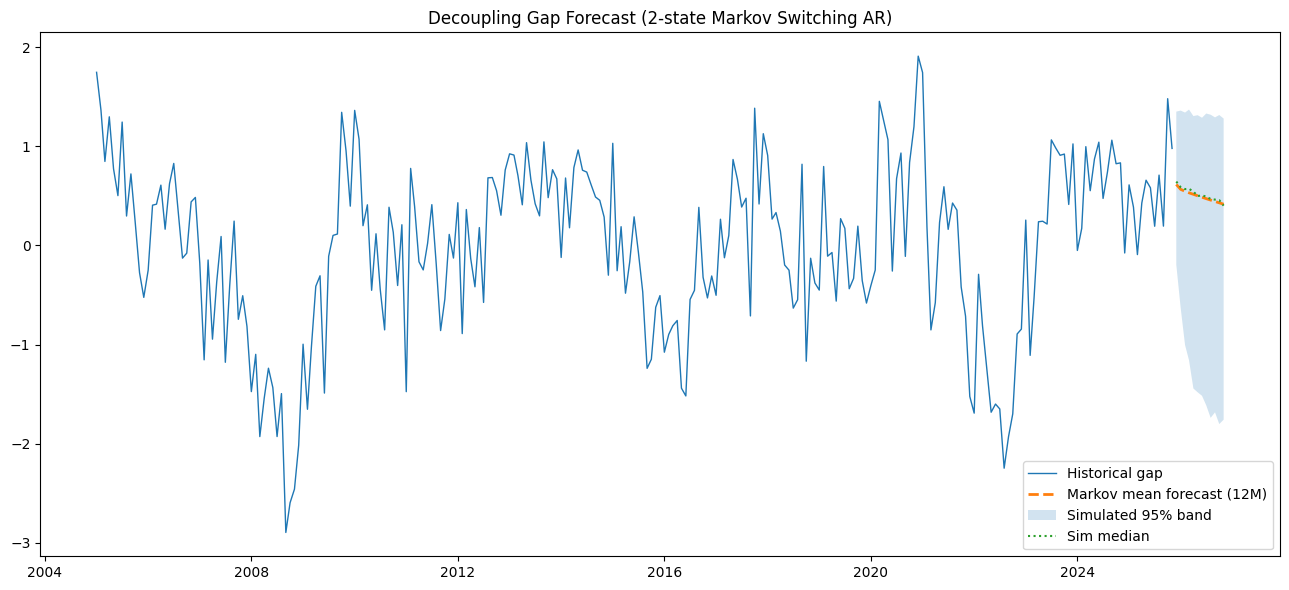

,markov_mean_forecast,median,lower_95,upper_95,P_state0_f,P_state1_f
2025-12-01,0.615072,0.643935,-0.194175,1.349540,0.880986,0.119014
2026-01-01,0.565404,0.587284,-0.630799,1.359572,0.851474,0.148526
2026-02-01,0.546155,0.568208,-1.004464,1.339645,0.823398,0.176602
2026-03-01,0.530520,0.570832,-1.157919,1.369966,0.796688,0.203312
2026-04-01,0.515487,0.542881,-1.442619,1.304322,0.771278,0.228722
2026-05-01,0.500677,0.497465,-1.480834,1.313196,0.747105,0.252895
2026-06-01,0.486046,0.505330,-1.516468,1.287564,0.724108,0.275892
2026-07-01,0.471600,0.491668,-1.612704,1.330147,0.702230,0.297770
2026-08-01,0.457349,0.468354,-1.738630,1.318013,0.681416,0.318584
2026-09-01,0.443306,0.461930,-1.683151,1.291154,0.661616,0.338384


In [27]:
# =========================
# [셀 7] Markov로 gap 12개월 예측 경로 + 시뮬레이션 밴드
#   - 셀5에서 P 추출 완료
#   - 셀6에서 c, phi, sigma / probs(P_state0,1) 준비 완료
# =========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# (1) 기본 설정
# ------------------------------------------------------------
h = 12                 # 12개월 ahead
N = 2000               # 시뮬 경로 수
rng = np.random.default_rng(42)

# 마지막 관측값
y_last = float(pd.Series(np.asarray(y).ravel(), index=y.index).iloc[-1])

# 마지막 상태확률 (표준 컬럼명: P_state0, P_state1)
pi = probs.iloc[-1].values.reshape(1, -1)  # (1,2)

# 미래 인덱스
future_index = pd.date_range(y.index[-1] + pd.offsets.MonthBegin(1), periods=h, freq="MS")

# ------------------------------------------------------------
# (2) 12개월 ahead 점예측(기대값 경로)
#     - 상태확률을 1-step forward 시키고, 그 확률로 AR(1) 기대값 가중
# ------------------------------------------------------------
mean_path = []
pi_path = []

y_hat = y_last
cur = pi.copy()

for step in range(1, h + 1):
    # 상태확률 1-step forward
    cur = cur @ P
    pi_path.append(cur.flatten())

    # 상태확률 가중 기대값
    y_next = 0.0
    for s in (0, 1):
        y_next += float(cur[0, s]) * (c[s] + phi[s] * y_hat)

    mean_path.append(y_next)
    y_hat = y_next

mean_path = pd.Series(mean_path, index=future_index, name="markov_mean_forecast")
pi_path = pd.DataFrame(pi_path, index=future_index, columns=["P_state0_f", "P_state1_f"])

display(pi_path.head())
display(mean_path.head())

# ------------------------------------------------------------
# (3) Monte Carlo 시뮬레이션 (95% 밴드)
#     - 초기 상태는 마지막 스무딩 확률로 샘플링
#     - 이후 전이확률 P로 상태 전이
#     - 각 상태별 AR(1)로 gap 생성
# ------------------------------------------------------------
sim = np.zeros((N, h), dtype=float)

p0 = float(probs.iloc[-1]["P_state0"])
p1 = float(probs.iloc[-1]["P_state1"])

for n in range(N):
    # 초기 상태
    state = 0 if rng.random() < p0 else 1
    y_sim = y_last

    for t in range(h):
        # 다음 상태 전이
        r = rng.random()
        if state == 0:
            state = 0 if r < P[0, 0] else 1
        else:
            state = 0 if r < P[1, 0] else 1

        # 상태별 AR(1)
        eps = rng.normal(0.0, sigma[state])
        y_sim = c[state] + phi[state] * y_sim + eps
        sim[n, t] = y_sim

lower = pd.Series(np.quantile(sim, 0.025, axis=0), index=future_index, name="lower_95")
upper = pd.Series(np.quantile(sim, 0.975, axis=0), index=future_index, name="upper_95")
median = pd.Series(np.quantile(sim, 0.50,  axis=0), index=future_index, name="median")

# ------------------------------------------------------------
# (4) 그래프 출력
# ------------------------------------------------------------
plt.figure(figsize=(13, 6))
plt.plot(y.index, np.asarray(y).ravel(), linewidth=1, label="Historical gap")
plt.plot(mean_path.index, mean_path.values, linewidth=2, linestyle="--", label="Markov mean forecast (12M)")
plt.fill_between(future_index, lower.values, upper.values, alpha=0.2, label="Simulated 95% band")
plt.plot(median.index, median.values, linewidth=1.5, linestyle=":", label="Sim median")

plt.title("Decoupling Gap Forecast (2-state Markov Switching AR)")
plt.legend()
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# (5) 결과 테이블(필요하면)
# ------------------------------------------------------------
forecast_df = pd.concat([mean_path, median, lower, upper, pi_path], axis=1)
display(forecast_df.head(12))